<a href="https://colab.research.google.com/github/yoshimabudiman-spec/mnist_cnn_model/blob/main/mnist_cnn_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#MNIST Handwritten Digit Classification Using CNN

The MNIST dataset, consisting of 280,000 handwritten digit images, and the EMNIST dataset, containing 383,600 handwritten digits and letters, are widely used benchmarks for evaluating image classification algorithms. In this project, we implement a Convolutional Neural Network (CNN) with no bias terms to explore the effects on learning dynamics and regularization. To reduce overfitting and improve generalization, we apply dropout layers and L2 regularization, aiming for more balanced training and validation curves. The datasets are split into 70% for training and 30% for testing, allowing robust evaluation of model performance on unseen data.

<small>Created by: Yosef (N16157011) and Jack (N16141662)\
Department of Mechanical Engineering, National Cheng Kung University

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, regularizers
from sklearn.metrics import confusion_matrix
import seaborn as sns
import tensorflow_datasets as tfds

In [ ]:
# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Settings
EPOCHS = 100
BATCH_SIZE = 64
L2_VALUE = 0.0005

In [ ]:
# Load EMNIST digits
ds_train_digits, ds_test_digits = tfds.load(
    'emnist/digits', split=['train', 'test'], as_supervised=True
)

x_train_digits = np.array([np.array(img) for img, lbl in tfds.as_numpy(ds_train_digits)])
y_train_digits = np.array([lbl for img, lbl in tfds.as_numpy(ds_train_digits)])

x_test_digits = np.array([np.array(img) for img, lbl in tfds.as_numpy(ds_test_digits)])
y_test_digits = np.array([lbl for img, lbl in tfds.as_numpy(ds_test_digits)])

# Load EMNIST letters
ds_train_letters, ds_test_letters = tfds.load(
    'emnist/letters', split=['train', 'test'], as_supervised=True
)

x_train_letters = np.array([np.array(img) for img, lbl in tfds.as_numpy(ds_train_letters)])
y_train_letters = np.array([lbl + 10 for img, lbl in tfds.as_numpy(ds_train_letters)])

x_test_letters = np.array([np.array(img) for img, lbl in tfds.as_numpy(ds_test_letters)])
y_test_letters = np.array([lbl + 10 for img, lbl in tfds.as_numpy(ds_test_letters)])

# Combine numbers + letters
x_train_all = np.concatenate((x_train_digits, x_train_letters), axis=0)
y_train_all = np.concatenate((y_train_digits, y_train_letters), axis=0)

x_test_all = np.concatenate((x_test_digits, x_test_letters), axis=0)
y_test_all = np.concatenate((y_test_digits, y_test_letters), axis=0)

x_all = np.concatenate((x_train_all, x_test_all), axis=0)
y_all = np.concatenate((y_train_all, y_test_all), axis=0)

print("Total images:", x_all.shape)
print("Total labels:", y_all.shape)
print("Label range:", np.min(y_all), "–", np.max(y_all))  # 0–35 (0-9 digits, 10-35 letters)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

...

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/letters/incomplete.EITCJX_3.1.0/emnist-train.tfrecord*...:   0%|   …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/letters/incomplete.EITCJX_3.1.0/emnist-test.tfrecord*...:   0%|    …

Dataset emnist downloaded and prepared to /root/tensorflow_datasets/emnist/letters/3.1.0. Subsequent calls will reuse this data.
Total images: (383600, 28, 28, 1)
Total labels: (383600,)
Label range: 0 – 36


In [ ]:
# Shuffle dataset
indices = np.arange(len(x_all))
np.random.shuffle(indices)
x_all = x_all[indices]
y_all = y_all[indices]

# Split dataset 70% train/30% test
split_index = int(0.70 * len(x_all))

x_train = x_all[:split_index]
y_train = y_all[:split_index]

x_test = x_all[split_index:]
y_test = y_all[split_index:]

print("\nAfter 70/30 split:")
print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

# Preprocess data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Determine the number of classes from the maximum label in y_all
num_classes = int(np.max(y_all)) + 1

y_train_onehot = tf.keras.utils.to_categorical(y_train, num_classes)
y_test_onehot = tf.keras.utils.to_categorical(y_test, num_classes)

print("\nAfter preprocessing:")
print("Training images:", x_train.shape)
print("Training labels:", y_train_onehot.shape)
print("Testing images:", x_test.shape)
print("Testing labels:", y_test_onehot.shape)


After 70/30 split:
Training images: (268520, 28, 28, 1)
Training labels: (268520,)
Testing images: (115080, 28, 28, 1)
Testing labels: (115080,)

After preprocessing:
Training images: (268520, 28, 28, 1)
Training labels: (268520, 37)
Testing images: (115080, 28, 28, 1)
Testing labels: (115080, 37)


In [ ]:
# Build CNN model with bias + L2 + dropout
def build_cnn_model_with_bias():
    model = models.Sequential(name="MNIST_CNN_WithBias_Regularized")

    # Input layer
    model.add(layers.Input(shape=(28, 28, 1)))

    # Conv Layer 1
    model.add(
        layers.Conv2D(
            filters=8,
            kernel_size=(5, 5),
            activation="relu",
            use_bias=True,  # Bias enabled
            kernel_regularizer=regularizers.l2(L2_VALUE)
        )
    )
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Dropout(0.10))

    # Conv Layer 2
    model.add(
        layers.Conv2D(
            filters=16,
            kernel_size=(5, 5),
            activation="relu",
            use_bias=True,  # Bias enabled
            kernel_regularizer=regularizers.l2(L2_VALUE)
        )
    )
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Dropout(0.15))

    # Flatten before Dense
    model.add(layers.Flatten())

    # Dense Layer 1
    model.add(
        layers.Dense(
            30,
            activation="relu",
            use_bias=True,  # Bias enabled
            kernel_regularizer=regularizers.l2(L2_VALUE)
        )
    )
    model.add(layers.Dropout(0.20))

    # Output Layer
    model.add(
        layers.Dense(
            num_classes,
            activation="softmax",
            use_bias=True,  # Bias enabled
            kernel_regularizer=regularizers.l2(L2_VALUE)
        )
    )

    # Optimizer
    optimizer = tf.keras.optimizers.Adam(
        learning_rate=0.0003
    )

    # Compile model
    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

# Build and summarize model
model = build_cnn_model_with_bias()
print("\nModel Summary:")
model.summary()


Model Summary:


Model: "MNIST_CNN_WithBias_Regularized"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 8)      │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         3,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 30)             │         7,710 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 37)             │         1,147 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,281 (47.97 KB)

 Trainable params: 12,281 (47.97 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Evaluate before training
print("\nEvaluating model before training...")

initial_train_loss, initial_train_acc = model.evaluate(
    x_train,
    y_train_onehot,
    verbose=0
)

initial_val_loss, initial_val_acc = model.evaluate(
    x_test,
    y_test_onehot,
    verbose=0
)

print("Initial training loss:", initial_train_loss)
print("Initial training accuracy:", initial_train_acc)
print("Initial validation loss:", initial_val_loss)
print("Initial validation accuracy:", initial_val_acc)


Evaluating model before training...
Initial training loss: 3.654029130935669
Initial training accuracy: 0.047910768538713455
Initial validation loss: 3.653991222381592
Initial validation accuracy: 0.04749739170074463


In [ ]:
# Train model
print("\nTraining model...")

history = model.fit(
    x_train,
    y_train_onehot,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_test, y_test_onehot),
    verbose=1
)

# Combine epoch 0 with History
epochs = list(range(0, EPOCHS + 1))

train_loss = [initial_train_loss] + history.history["loss"]
val_loss = [initial_val_loss] + history.history["val_loss"]

train_acc = [initial_train_acc] + history.history["accuracy"]
val_acc = [initial_val_acc] + history.history["val_accuracy"]


Training model...
Epoch 1/100
4196/4196 ━━━━━━━━━━━━━━━━━━━━ 29s 6ms/step - accuracy: 0.6904 - loss: 1.2223 - val_accuracy: 0.8499 - val_loss: 0.5726
Epoch 2/100
4196/4196 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.8091 - loss: 0.7252 - val_accuracy: 0.8747 - val_loss: 0.4831
Epoch 3/100
4196/4196 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - accuracy: 0.8307 - loss: 0.6457 - val_accuracy: 0.8849 - val_loss: 0.4504
Epoch 4/100
4196/4196 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - accuracy: 0.8417 - loss: 0.6042 - val_accuracy: 0.8911 - val_loss: 0.4277
Epoch 5/100
4196/4196 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - accuracy: 0.8492 - loss: 0.5824 - val_accuracy: 0.8949 - val_loss: 0.4139
Epoch 6/100
4196/4196 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - accuracy: 0.8539 - loss: 0.5648 - val_accuracy: 0.8989 - val_loss: 0.4030
Epoch 7/100
4196/4196 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - accuracy: 0.8581 - loss: 0.5522 - val_accuracy: 0.9002 - val_loss: 0.3975
Epoch 8/100
4196/4196 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step -

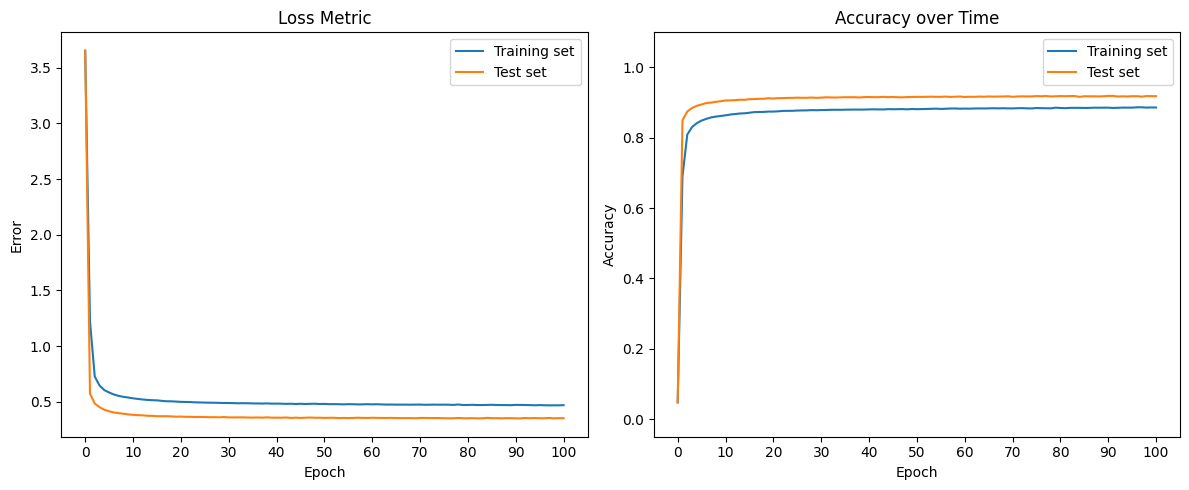


Best Test Accuracy: 0.92% at Epoch 91


In [ ]:
# Plot loss-accuracy curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, label="Training set")
plt.plot(epochs, val_loss, label="Test set")
plt.title("Loss Metric")
plt.xlabel("Epoch")
plt.ylabel("Error")
plt.xticks(np.arange(0, EPOCHS + 1, 10))
plt.legend()
plt.grid(False)

plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc, label="Training set")
plt.plot(epochs, val_acc, label="Test set")
plt.title("Accuracy over Time")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(np.arange(0, EPOCHS + 1, 10))
plt.ylim(-0.05, 1.10)
plt.legend()
plt.grid(False)

plt.tight_layout()
plt.show()

# Best test accuracy within full range
best_val_acc = max(val_acc)
best_epoch = val_acc.index(best_val_acc)
print(f"\nBest Test Accuracy: {best_val_acc:.2f}% at Epoch {best_epoch}")

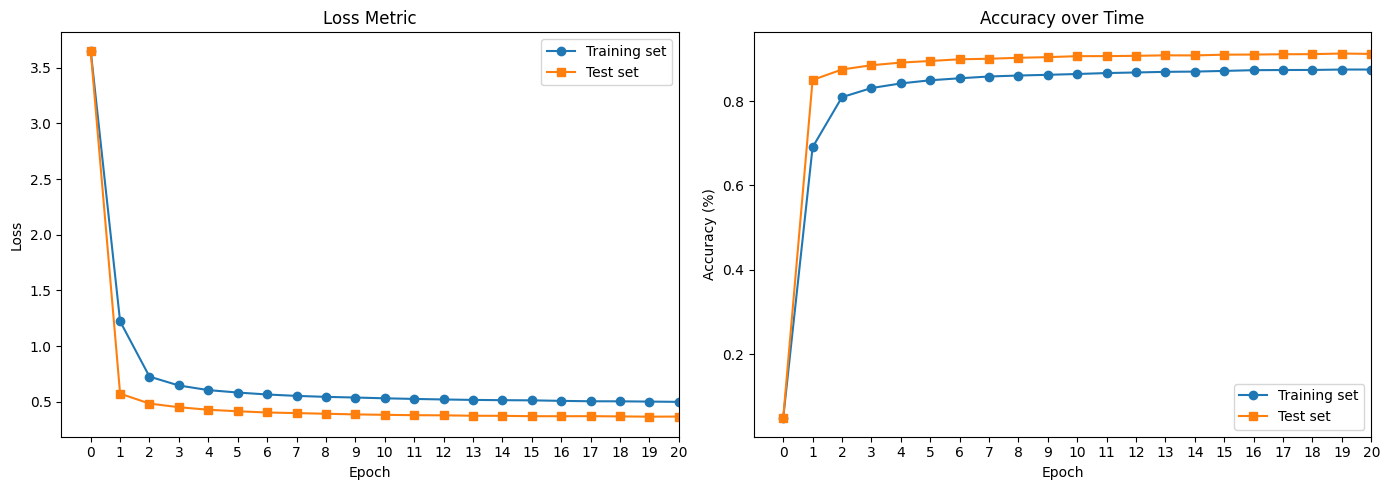

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
ax1.plot(train_loss, label='Training set', marker='o')
ax1.plot(val_loss, label='Test set', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Metric')
ax1.set_xlim(-1, 20)
ax1.set_xticks(range(0, 21, 1))
ax1.legend()

# Accuracy plot
ax2.plot(train_acc, label='Training set', marker='o')
ax2.plot(val_acc, label='Test set', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy over Time')
ax2.set_xlim(-1, 20)
ax2.set_xticks(range(0, 21, 1))
ax2.legend()

plt.tight_layout()
plt.show()

3597/3597 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step


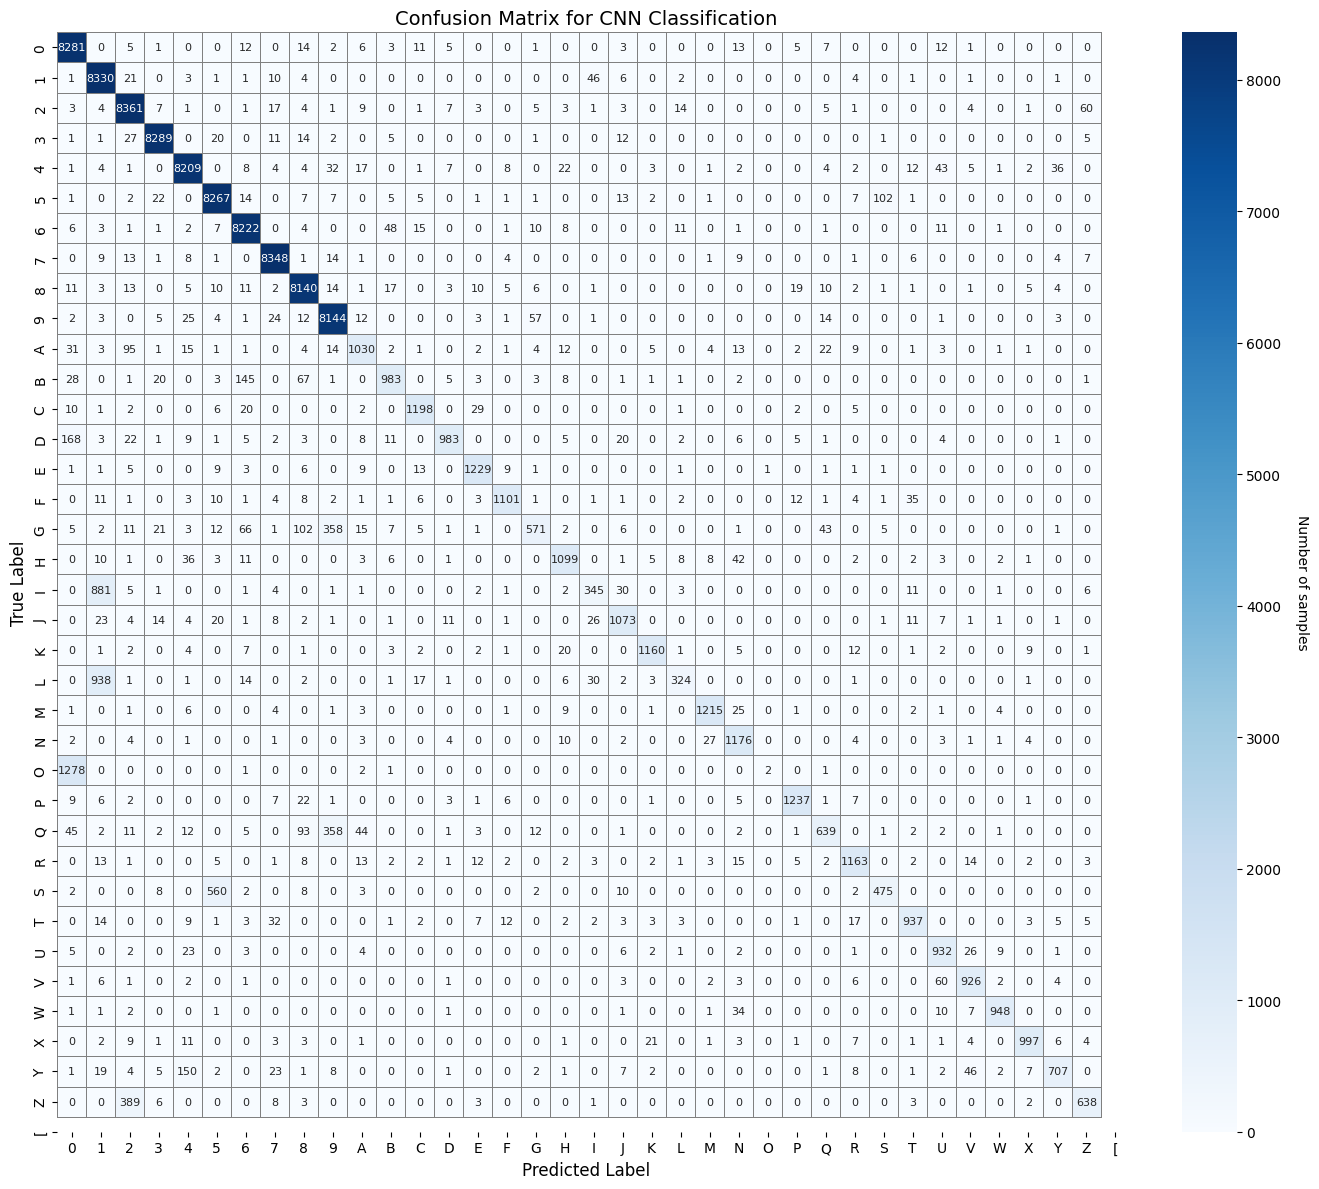

In [ ]:
# Mapping labels to characters
def label_to_char(label):
    if label < 10:
        return str(label)
    else:
        return chr(ord('A') + label - 10)

# Predict class for test set
y_pred_probs = model.predict(x_test)
predicted_labels = np.argmax(y_pred_probs, axis=1)
true_labels = np.argmax(y_test_onehot, axis=1)

# Generate confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)
labels_char = [label_to_char(i) for i in range(num_classes)]
plt.figure(figsize=(14,12))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_char, yticklabels=labels_char,
            cbar=True, annot_kws={"size":8},
            linewidths=0.5, linecolor='gray')

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix for CNN Classification", fontsize=14)

colorbar = plt.gcf().axes[-1]
colorbar.set_ylabel('Number of samples', rotation=270, labelpad=20)

plt.tight_layout()
plt.show()

In [ ]:
# Calculate per-class accuracy for the Keras model
class_correct = [0. for _ in range(num_classes)]
class_total = [0. for _ in range(num_classes)]

# Get predictions from the Keras model
y_pred_probs = model.predict(x_test, verbose=0)
predicted_labels = np.argmax(y_pred_probs, axis=1)
true_labels = np.argmax(y_test_onehot, axis=1)

for i in range(len(true_labels)):
    label = true_labels[i]
    if predicted_labels[i] == label:
        class_correct[label] += 1
    class_total[label] += 1

# Print per-class accuracy
print("Per-class Accuracy:")
print("-" * 30)
for i in range(num_classes):
    char_label = label_to_char(i)
    if class_total[i] > 0:
        accuracy = 100 * class_correct[i] / class_total[i]
        print(f'Label {char_label}: {accuracy:.2f}% ({int(class_correct[i])}/{int(class_total[i])})')
    else:
        print(f'Label {char_label}: No samples in test set')

# Find most Confused Pairs
print("\nMost Confused Pairs:")
print("-" * 30)

# Recompute confusion matrix to ensure it's based on current predictions
cm = confusion_matrix(true_labels, predicted_labels, labels=range(num_classes))

# Normalize confusion matrix by true labels
cm_normalized = np.zeros_like(cm, dtype=float)
sum_rows = cm.sum(axis=1)
for i in range(num_classes):
    if sum_rows[i] > 0:
        cm_normalized[i, :] = cm[i, :].astype('float') / sum_rows[i]

np.fill_diagonal(cm_normalized, 0)

confused_pairs = []
for i in range(num_classes):
    for j in range(num_classes):
        if i != j and class_total[i] > 0 and cm_normalized[i, j] > 0.005:
            confused_pairs.append((label_to_char(i), label_to_char(j), cm_normalized[i, j]))

confused_pairs.sort(key=lambda x: x[2], reverse=True)
for true_label_char, pred_label_char, conf_rate in confused_pairs[:10]:
    print(f"{true_label_char} → {pred_label_char}: {conf_rate*100:.1f}%")

Per-class Accuracy:
------------------------------
Label 0: 98.80% (8281/8382)
Label 1: 98.79% (8330/8432)
Label 2: 98.18% (8361/8516)
Label 3: 98.81% (8289/8389)
Label 4: 97.39% (8209/8429)
Label 5: 97.73% (8267/8459)
Label 6: 98.43% (8222/8353)
Label 7: 99.05% (8348/8428)
Label 8: 98.13% (8140/8295)
Label 9: 97.98% (8144/8312)
Label A: No samples in test set
Label B: 80.59% (1030/1278)
Label C: 77.22% (983/1273)
Label D: 93.89% (1198/1276)
Label E: 78.02% (983/1260)
Label F: 95.20% (1229/1291)
Label G: 90.99% (1101/1210)
Label H: 46.09% (571/1239)
Label I: 88.34% (1099/1244)
Label J: 26.64% (345/1295)
Label K: 88.60% (1073/1211)
Label L: 94.00% (1160/1234)
Label M: 24.14% (324/1342)
Label N: 95.29% (1215/1275)
Label O: 94.61% (1176/1243)
Label P: 0.16% (2/1285)
Label Q: 94.50% (1237/1309)
Label R: 51.66% (639/1237)
Label S: 91.07% (1163/1277)
Label T: 44.31% (475/1072)
Label U: 88.23% (937/1062)
Label V: 91.64% (932/1017)
Label W: 90.96% (926/1018)
Label X: 94.14% (948/1007)
Label Y:

Sample Model Predictions:


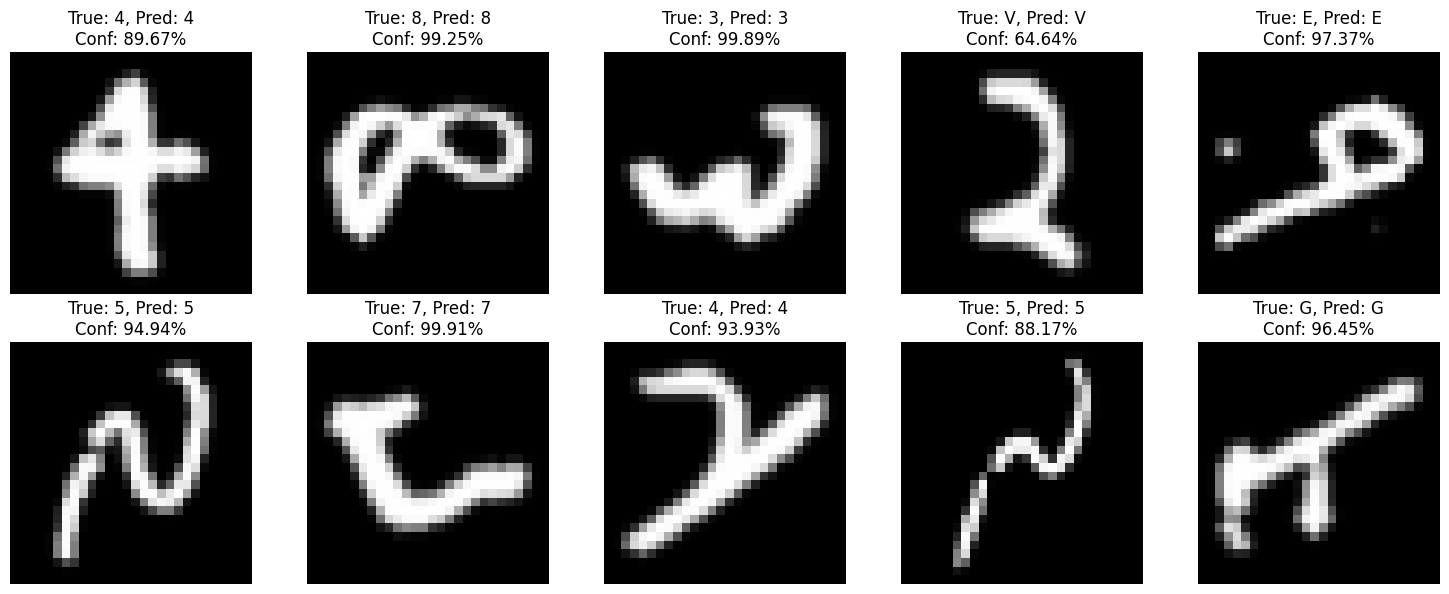

In [ ]:
def show_images(images, titles, rows=1, cols=None, figsize=(10, 10)):
    if cols is None:
        cols = len(images) // rows
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.flatten()
    for i, (img, title) in enumerate(zip(images, titles)):
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(title)
        axes[i].axis('off')
    for j in range(i + 1, len(axes)): # Turn off any unused subplots
        axes[j].axis('off')
    plt.tight_layout()
    plt.show()


def show_model_predictions(keras_model, x_test_data, y_test_onehot_data, num_images=10):
    """Display Keras model predictions on test images."""

    # Select random images from the test set
    indices = np.random.choice(len(x_test_data), num_images, replace=False)
    sample_images = x_test_data[indices]
    sample_true_onehot = y_test_onehot_data[indices]
    sample_true_labels = np.argmax(sample_true_onehot, axis=1)

    # Get predictions from the Keras model
    sample_predictions_raw = keras_model.predict(sample_images, verbose=0)
    sample_predicted_labels = np.argmax(sample_predictions_raw, axis=1)
    sample_confidences = np.max(sample_predictions_raw, axis=1)

    images_to_show = []
    titles_to_show = []

    for i in range(num_images):
        img = sample_images[i].squeeze()
        true_char = label_to_char(sample_true_labels[i])
        pred_char = label_to_char(sample_predicted_labels[i])
        confidence = sample_confidences[i]

        if sample_true_labels[i] == sample_predicted_labels[i]:
            title = f'True: {true_char}, Pred: {pred_char}\nConf: {confidence:.2%}'
        else:
            title = f'True: {true_char}, Pred: {pred_char} (WRONG)\nConf: {confidence:.2%}'

        images_to_show.append(img)
        titles_to_show.append(title)

    rows = int(np.ceil(num_images / 5))
    show_images(images_to_show, titles_to_show, rows=rows, cols=5, figsize=(15, 3 * rows))

print("Sample Model Predictions:")
show_model_predictions(model, x_test, y_test_onehot, num_images=10)

In [ ]:
# Final evaluation
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test_onehot,
    verbose=0
)

test_accuracy_percent = test_accuracy * 100
test_error_percent = (1 - test_accuracy) * 100

print("\nFinal Test Results:")
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy_percent:.2f}%")
print(f"Test error: {test_error_percent:.2f}%")


Final Test Results:
Test loss: 0.3522
Test accuracy: 91.83%
Test error: 8.17%


In [ ]:
# Save model
test_loss, test_accuracy = model.evaluate(x_test, y_test_onehot, verbose=0)
test_error_percent = (1 - test_accuracy) * 100
filename = f"MNIST_{test_error_percent:.2f}%_Yosef_Budiman.h5"
model.save(filename, save_format="h5")
print(f"\nModel saved as {filename}")
print("\nDone.")


Model saved as MNIST_8.17%_Yosef_Budiman.h5

Done.
